In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from natsort import natsorted


DATASET_PATH = r"D:\sem9\archive\VideoDataset\Cycles\Cycle_0"


if os.path.exists(DATASET_PATH):
    print(f"Successfully connected to directory: {DATASET_PATH}")

    video_files = natsorted(glob.glob(os.path.join(DATASET_PATH, "*.mp4")))
    print(f"Found {len(video_files)} video tasks inside Cycle_0:")
    for vf in video_files:
        print(f" - {os.path.basename(vf)}")
else:
    print(f"ERROR: The path {DATASET_PATH} does not exist. Please check your drive letter or folder names.")

Successfully connected to directory: D:\sem9\archive\VideoDataset\Cycles\Cycle_0
Found 7 video tasks inside Cycle_0:
 - Cycle_0_task_0.mp4
 - Cycle_0_task_1.mp4
 - Cycle_0_task_2.mp4
 - Cycle_0_task_3.mp4
 - Cycle_0_task_4.mp4
 - Cycle_0_task_5.mp4
 - Cycle_0_task_6.mp4


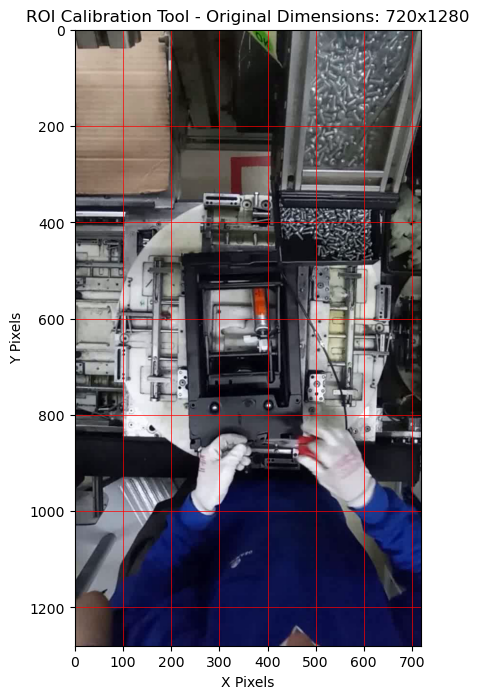

ACTION REQUIRED: Look at the red grid lines above and estimate the bounding boxes for your zones.


In [2]:

if len(video_files) > 0:
    cap = cv2.VideoCapture(video_files[0])
    ret, frame = cap.read()
    cap.release()

    if ret:
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        
        plt.figure(figsize=(12, 8))
        plt.imshow(frame_rgb)
        plt.grid(True, which='both', color='red', linestyle='-', linewidth=0.5)
        plt.title(f"ROI Calibration Tool - Original Dimensions: {frame.shape[1]}x{frame.shape[0]}")
        plt.xlabel("X Pixels")
        plt.ylabel("Y Pixels")
        plt.show()
        
        print("ACTION REQUIRED: Look at the red grid lines above and estimate the bounding boxes for your zones.")
    else:
        print("Error: Could not read a frame from the first video file.")
else:
    print("Error: No video files available to calibrate.")

In [3]:


WORKSTATION_ROIS = {
    "Left_Material_Bin": (0, 0, 220, 400),
    
    "Right_Screw_Feeder": (450, 0, 700, 450),
    
    "Center_Assembly_Jig": (200, 450, 550, 850)
}

print("Workstation ROI coordinates registered successfully.")
print("Notice how we intentionally ignored the bottom area (Y > 850) to filter out the operator's shoulder/body movements.")

Workstation ROI coordinates registered successfully.
Notice how we intentionally ignored the bottom area (Y > 850) to filter out the operator's shoulder/body movements.


In [4]:

class ManufacturingMotionEngine:
    def __init__(self, rois, min_contour_area=2500):
        self.rois = rois
        self.min_contour_area = min_contour_area
        self.subtractor = cv2.createBackgroundSubtractorMOG2(history=200, varThreshold=16, detectShadows=True)
        
    def analyze_frame(self, frame):
        display_frame = frame.copy()
        zone_metrics = {}
        
        fg_mask = self.subtractor.apply(frame)
        
        _, clean_mask = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
        clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)
        
        for zone_name, (x1, y1, x2, y2) in self.rois.items():
            roi_mask = clean_mask[y1:y2, x1:x2]
            roi_total_pixels = (x2 - x1) * (y2 - y1)
            
            contours, _ = cv2.findContours(roi_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            significant_motion_pixels = 0
            
            for contour in contours:
                area = cv2.contourArea(contour)
                if area > self.min_contour_area:
                    significant_motion_pixels += area
            
            activity_percentage = (significant_motion_pixels / roi_total_pixels) * 100
            zone_metrics[zone_name] = round(activity_percentage, 2)
            
            is_active = activity_percentage > 3.0
            box_color = (0, 0, 255) if is_active else (0, 255, 0)
            
            cv2.rectangle(display_frame, (x1, y1), (x2, y2), box_color, 2)
            cv2.putText(display_frame, f"{zone_name}: {zone_metrics[zone_name]}%", 
                        (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 1)
            
        return display_frame, zone_metrics

print("Tuned Motion Analysis Engine loaded. Shadow filtering increased.")

Tuned Motion Analysis Engine loaded. Shadow filtering increased.


In [5]:

engine = ManufacturingMotionEngine(rois=WORKSTATION_ROIS)

time_series_data = {zone: [] for zone in WORKSTATION_ROIS.keys()}
task_transition_frames = []
cumulative_frames = 0

print("Processing manufacturing tasks in sequence. Focus on the popup window. Press 'q' to stop.")

for current_task_path in video_files:
    task_name = os.path.basename(current_task_path)
    cap = cv2.VideoCapture(current_task_path)
    
    if not cap.isOpened():
        print(f"Skipping unreadable file: {task_name}")
        continue
        
    print(f"Currently Analyzing Step: {task_name}...")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break  # Current task completed, move to next file
            
        annotated_frame, metrics = engine.analyze_frame(frame)
        cumulative_frames += 1
        
        for zone, score in metrics.items():
            time_series_data[zone].append(score)
            
        cv2.putText(annotated_frame, f"Processing Segment: {task_name}", (20, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        
        cv2.imshow("Industrial Line Analytics Engine", annotated_frame)
        
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Processing halted prematurely by user.")
            cap.release()
            cv2.destroyAllWindows()
            break
            
    cap.release()
    task_transition_frames.append(cumulative_frames)

cv2.destroyAllWindows()
print(f"Simulation completed. Analyzed {cumulative_frames} global sequence frames.")

Processing manufacturing tasks in sequence. Focus on the popup window. Press 'q' to stop.
Currently Analyzing Step: Cycle_0_task_0.mp4...
Currently Analyzing Step: Cycle_0_task_1.mp4...
Currently Analyzing Step: Cycle_0_task_2.mp4...
Currently Analyzing Step: Cycle_0_task_3.mp4...
Currently Analyzing Step: Cycle_0_task_4.mp4...
Currently Analyzing Step: Cycle_0_task_5.mp4...
Currently Analyzing Step: Cycle_0_task_6.mp4...
Simulation completed. Analyzed 731 global sequence frames.


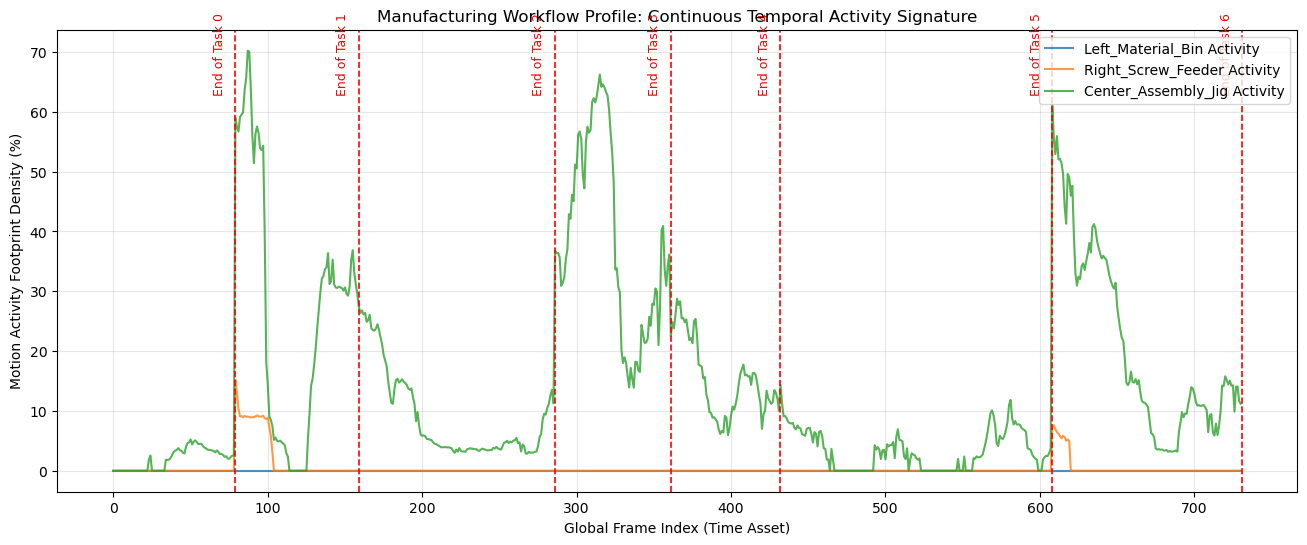

In [6]:

plt.figure(figsize=(16, 6))

for zone_name, motion_history in time_series_data.items():
    plt.plot(motion_history, label=f"{zone_name} Activity", alpha=0.8)

for idx, transition_point in enumerate(task_transition_frames):
    plt.axvline(x=transition_point, color='red', linestyle='--', linewidth=1.2)
    plt.text(transition_point - (cumulative_frames * 0.02), max(max(v) for v in time_series_data.values()) * 0.9, 
             f"End of Task {idx}", rotation=90, color='red', fontsize=9)

plt.title("Manufacturing Workflow Profile: Continuous Temporal Activity Signature")
plt.xlabel("Global Frame Index (Time Asset)")
plt.ylabel("Motion Activity Footprint Density (%)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.show()

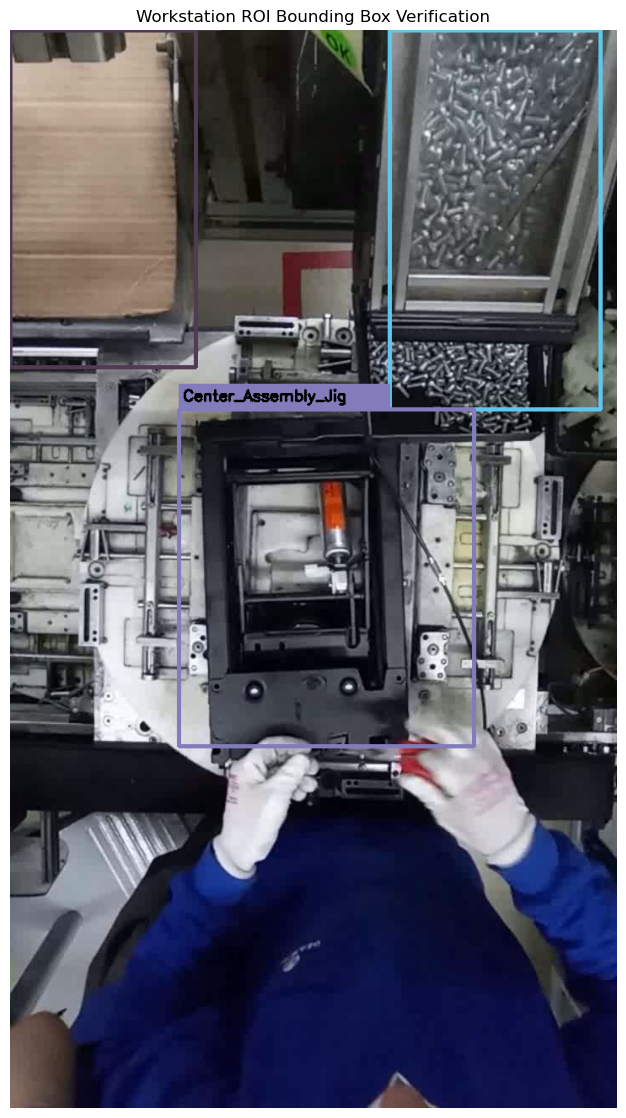

In [7]:

import random

test_video = video_files[0]
cap = cv2.VideoCapture(test_video)
ret, frame = cap.read()
cap.release()

if ret:
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    for zone_name, (x1, y1, x2, y2) in WORKSTATION_ROIS.items():
        color = (random.randint(50, 255), random.randint(50, 255), random.randint(50, 255))
        
        cv2.rectangle(frame_rgb, (x1, y1), (x2, y2), color, 4)
        
        cv2.rectangle(frame_rgb, (x1, y1-30), (x1 + 250, y1), color, -1)
        cv2.putText(frame_rgb, zone_name, (x1 + 5, y1 - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 2)

    plt.figure(figsize=(10, 14))
    plt.imshow(frame_rgb)
    plt.title("Workstation ROI Bounding Box Verification")
    plt.axis("off") 
    plt.show()
else:
    print("Error: Could not load the video frame.")

--- CONCURRENT FACTORY EVENT LOG ---
[Frame 072] >> ACTIVATED: Center_Assembly_Jig
[Frame 079] >> ACTIVATED: Right_Screw_Feeder
[Frame 102] << COMPLETED: Right_Screw_Feeder (Duration: 23 frames)
[Frame 108] << COMPLETED: Center_Assembly_Jig (Duration: 36 frames)
[Frame 124] >> ACTIVATED: Center_Assembly_Jig
[Frame 206] << COMPLETED: Center_Assembly_Jig (Duration: 82 frames)
[Frame 274] >> ACTIVATED: Center_Assembly_Jig
[Frame 457] << COMPLETED: Center_Assembly_Jig (Duration: 183 frames)
[Frame 564] >> ACTIVATED: Center_Assembly_Jig
[Frame 592] << COMPLETED: Center_Assembly_Jig (Duration: 28 frames)
[Frame 601] >> ACTIVATED: Center_Assembly_Jig
[Frame 677] << COMPLETED: Center_Assembly_Jig (Duration: 76 frames)
[Frame 687] >> ACTIVATED: Center_Assembly_Jig
--- END OF CYCLE ---


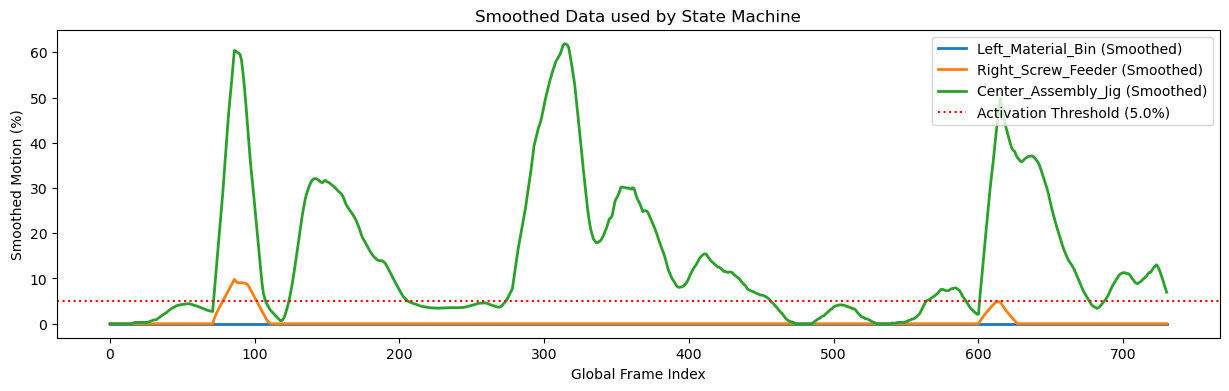

In [8]:
 
SMOOTHING_WINDOW = 15
ACTIVATION_THRESHOLD = 5.0 

smoothed_data = {}

for zone, data_array in time_series_data.items():
    box = np.ones(SMOOTHING_WINDOW) / SMOOTHING_WINDOW
    smoothed_data[zone] = np.convolve(data_array, box, mode='same')

print("--- CONCURRENT FACTORY EVENT LOG ---")

zone_status = {zone: {"is_active": False, "start_frame": 0} for zone in WORKSTATION_ROIS.keys()}

for frame_idx in range(len(smoothed_data["Center_Assembly_Jig"])):
    
    for zone in WORKSTATION_ROIS.keys():
        current_motion = smoothed_data[zone][frame_idx]
        
        if current_motion > ACTIVATION_THRESHOLD and not zone_status[zone]["is_active"]:
            zone_status[zone]["is_active"] = True
            zone_status[zone]["start_frame"] = frame_idx
            print(f"[Frame {frame_idx:03d}] >> ACTIVATED: {zone}")
            
        elif current_motion <= ACTIVATION_THRESHOLD and zone_status[zone]["is_active"]:
            duration = frame_idx - zone_status[zone]["start_frame"]
            
            if duration > 15:
                print(f"[Frame {frame_idx:03d}] << COMPLETED: {zone} (Duration: {duration} frames)")
            
            zone_status[zone]["is_active"] = False

print("--- END OF CYCLE ---")

import matplotlib.pyplot as plt
plt.figure(figsize=(15, 4))
for zone, data_array in smoothed_data.items():
    plt.plot(data_array, label=f"{zone} (Smoothed)", linewidth=2)
plt.axhline(y=ACTIVATION_THRESHOLD, color='r', linestyle=':', label='Activation Threshold (5.0%)')
plt.title("Smoothed Data used by State Machine")
plt.xlabel("Global Frame Index")
plt.ylabel("Smoothed Motion (%)")
plt.legend()
plt.show()

In [9]:

FPS = 30  
EXPECTED_SCREW_GRABS = 1 
MINIMUM_CYCLE_TIME = 20.0 

EXPECTED_SEQUENCE = ["Center_Assembly_Jig", "Right_Screw_Feeder", "Center_Assembly_Jig"]

print("==================================================")
print("       MANUFACTURING CYCLE ANALYTICS REPORT       ")
print("==================================================\n")

total_cycle_frames = len(smoothed_data["Center_Assembly_Jig"])
actual_sequence = []
zone_active = {zone: False for zone in WORKSTATION_ROIS.keys()}
screw_grab_count = 0
assembly_frames = 0

for frame_idx in range(total_cycle_frames):
    for zone in WORKSTATION_ROIS.keys():
        current_motion = smoothed_data[zone][frame_idx]
        
        if current_motion > ACTIVATION_THRESHOLD:
            if not zone_active[zone]:
                zone_active[zone] = True
                
                if len(actual_sequence) == 0 or actual_sequence[-1] != zone:
                    actual_sequence.append(zone)
                
                if zone == "Right_Screw_Feeder":
                    screw_grab_count += 1
        else:
            zone_active[zone] = False
            
        if zone == "Center_Assembly_Jig" and current_motion > ACTIVATION_THRESHOLD:
            assembly_frames += 1

print("--- TIMING & SEQUENCE EXTRACTED ---")
print(f"Total Cycle Time:      {total_cycle_frames / FPS:.2f} seconds")
print(f"Extracted Sequence:    {actual_sequence}")
print(f"Total Screw Fetches:   {screw_grab_count}")

print("\n--- WORKFLOW VALIDATION (SOP CHECK) ---")
sop_passed = True

if len(actual_sequence) >= len(EXPECTED_SEQUENCE) and actual_sequence[:3] == EXPECTED_SEQUENCE:
    print("[PASS] Sequence logic verified. Tasks were performed in the correct order.")
else:
    print(f"[FAIL] SEQUENCE ANOMALY! \n   Expected: {EXPECTED_SEQUENCE}\n   Observed: {actual_sequence}")
    sop_passed = False

if screw_grab_count == EXPECTED_SCREW_GRABS:
    print(f"[PASS] Correct number of screw fetches ({screw_grab_count}/{EXPECTED_SCREW_GRABS}).")
else:
    print(f"[FAIL] QUANTITY ANOMALY! Expected {EXPECTED_SCREW_GRABS} screw fetches, but detected {screw_grab_count}.")
    sop_passed = False

actual_cycle_time = total_cycle_frames / FPS
if actual_cycle_time < MINIMUM_CYCLE_TIME:
    print(f"[FAIL] TIMING ANOMALY! Cycle finished in {actual_cycle_time:.1f}s. Expected > {MINIMUM_CYCLE_TIME}s. (Skipped steps!)")
    sop_passed = False
else:
    print(f"[PASS] Minimum cycle time verified.")

print("\n==================================================")
if sop_passed:
    print("CYCLE STATUS: ACCEPTED (NO ANOMALIES DETECTED)")
else:
    print("CYCLE STATUS: REJECTED (DEFECT DETECTED - ALARM TRIGGERED)")
print("==================================================")

       MANUFACTURING CYCLE ANALYTICS REPORT       

--- TIMING & SEQUENCE EXTRACTED ---
Total Cycle Time:      24.37 seconds
Extracted Sequence:    ['Center_Assembly_Jig', 'Right_Screw_Feeder', 'Center_Assembly_Jig']
Total Screw Fetches:   1

--- WORKFLOW VALIDATION (SOP CHECK) ---
[PASS] Sequence logic verified. Tasks were performed in the correct order.
[PASS] Correct number of screw fetches (1/1).
[PASS] Minimum cycle time verified.

CYCLE STATUS: ACCEPTED (NO ANOMALIES DETECTED)


In [11]:

import numpy as np
import cv2

EXPECTED_SEQUENCE = ["Center_Assembly_Jig", "Right_Screw_Feeder", "Center_Assembly_Jig"]
EXPECTED_SCREWS = 1
MINIMUM_CYCLE_TIME = 20.0
ACTIVATION_THRESHOLD = 5.0

def run_virtual_inspector(video_list, test_name):
    print(f"[{test_name}] Processing videos... ", end="", flush=True)
    
    test_engine = ManufacturingMotionEngine(rois=WORKSTATION_ROIS, min_contour_area=2500)
    time_series = {zone: [] for zone in WORKSTATION_ROIS.keys()}
    
    for path in video_list:
        cap = cv2.VideoCapture(path)
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            _, metrics = test_engine.analyze_frame(frame)
            for zone, score in metrics.items():
                time_series[zone].append(score)
        cap.release()

    smoothed = {}
    for zone, data_array in time_series.items():
        smoothed[zone] = np.convolve(data_array, np.ones(15)/15, mode='same')

    total_frames = len(smoothed["Center_Assembly_Jig"])
    actual_sequence = []
    zone_active = {zone: False for zone in WORKSTATION_ROIS.keys()}
    screw_count = 0

    for i in range(total_frames):
        for zone in WORKSTATION_ROIS.keys():
            if smoothed[zone][i] > ACTIVATION_THRESHOLD:
                if not zone_active[zone]:
                    zone_active[zone] = True
                    if len(actual_sequence) == 0 or actual_sequence[-1] != zone:
                        actual_sequence.append(zone)
                    if zone == "Right_Screw_Feeder":
                        screw_count += 1
            else:
                zone_active[zone] = False

    actual_time = total_frames / 30.0
    errors = []
    
    if actual_time < MINIMUM_CYCLE_TIME:
        errors.append(f"Rushed/Skipped! (Time: {actual_time:.1f}s)")
    if screw_count != EXPECTED_SCREWS:
        errors.append(f"Wrong screw count ({screw_count})")
    if len(actual_sequence) < len(EXPECTED_SEQUENCE) or actual_sequence[:3] != EXPECTED_SEQUENCE:
        errors.append(f"Bad Sequence: {actual_sequence}")

    print("Done.")
    if len(errors) == 0:
        return "PASS", "No anomalies detected."
    else:
        return "FAIL", " | ".join(errors)

test_cases = {
    "Test 1: Perfect Run (Tasks 0-6)": video_files,
    "Test 2: Missing Screw Fetch (Tasks 2-6 only)": video_files[1:],
    "Test 3: Scrambled Order (Task 6 -> 1 -> 0)": [video_files[5], video_files[4], video_files[3], video_files[2], video_files[1], video_files[0]],
    "Test 4: Rushed Assembly (Only Tasks 0 & 1)": [video_files[0], video_files[1]]
}

print("==================================================")
print("     STARTING AUTOMATED ANOMALY TEST SUITE        ")
print("==================================================\n")

results_log = []

for test_name, specific_videos in test_cases.items():
    status, reason = run_virtual_inspector(specific_videos, test_name)
    results_log.append((test_name, status, reason))

print("\n==================================================")
print("               FINAL TEST REPORT                  ")
print("==================================================")
for name, status, reason in results_log:
    if status == "PASS":
        print(f" {name}\n   Result: ACCEPTED\n")
    else:
        print(f" {name}\n   Result: REJECTED\n   Anomalies Caught: {reason}\n")

     STARTING AUTOMATED ANOMALY TEST SUITE        

[Test 1: Perfect Run (Tasks 0-6)] Processing videos... Done.
[Test 2: Missing Screw Fetch (Tasks 2-6 only)] Processing videos... Done.
[Test 3: Scrambled Order (Task 6 -> 1 -> 0)] Processing videos... Done.
[Test 4: Rushed Assembly (Only Tasks 0 & 1)] Processing videos... Done.

               FINAL TEST REPORT                  
 Test 1: Perfect Run (Tasks 0-6)
   Result: ACCEPTED

 Test 2: Missing Screw Fetch (Tasks 2-6 only)
   Result: ACCEPTED

 Test 3: Scrambled Order (Task 6 -> 1 -> 0)
   Result: REJECTED
   Anomalies Caught: Bad Sequence: ['Center_Assembly_Jig', 'Right_Screw_Feeder']

 Test 4: Rushed Assembly (Only Tasks 0 & 1)
   Result: REJECTED
   Anomalies Caught: Rushed/Skipped! (Time: 5.3s)



Loading YOLOv8 AI Model...
Model loaded successfully!

Running AI Inference on Test Frame...

0: 640x384 2 persons, 215.4ms
Speed: 26.7ms preprocess, 215.4ms inference, 22.0ms postprocess per image at shape (1, 3, 640, 384)


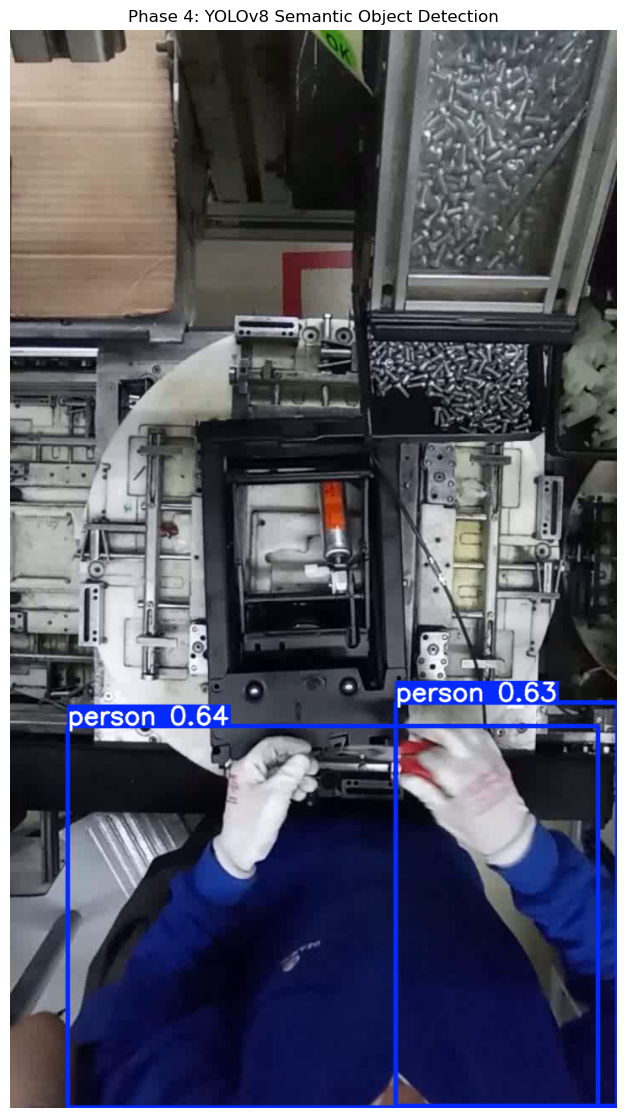


--- AI SENSOR DATA OUTPUT ---
Detected: [person] | Confidence: 63.5% | Coordinates: (68, 826) to (697, 1279)
Detected: [person] | Confidence: 62.9% | Coordinates: (457, 798) to (720, 1277)


In [12]:
# [CELL 10 - YOLOv8 INITIALIZATION & VISION TEST]
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# 1. Load the pre-trained YOLOv8 Nano model (downloads a small ~6MB file on first run)
print("Loading YOLOv8 AI Model...")
model = YOLO("yolov8n.pt")
print("Model loaded successfully!\n")

# 2. Grab a single test frame
test_video = video_files[0]
cap = cv2.VideoCapture(test_video)
ret, frame = cap.read()
cap.release()

if ret:
    print("Running AI Inference on Test Frame...")
    # conf=0.30 means we only accept detections the AI is at least 30% confident in
    results = model(frame, conf=0.30)
    
    # 3. Extract the image with AI bounding boxes automatically drawn
    annotated_frame = results[0].plot()
    annotated_frame_rgb = cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB)
    
    # 4. Display the results
    plt.figure(figsize=(10, 14))
    plt.imshow(annotated_frame_rgb)
    plt.title("Phase 4: YOLOv8 Semantic Object Detection")
    plt.axis("off")
    plt.show()
    
    # 5. Print out the raw data YOLO gives us
    print("\n--- AI SENSOR DATA OUTPUT ---")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        class_name = model.names[class_id]
        confidence = float(box.conf[0])
        
        # Get the pixel coordinates of what the AI found
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        print(f"Detected: [{class_name}] | Confidence: {confidence*100:.1f}% | Coordinates: ({x1}, {y1}) to ({x2}, {y2})")
else:
    print("Error: Could not load the video frame.")

In [14]:
# [CELL 11 - AI SPATIAL VERIFICATION LOGIC]

def ai_verifies_person_in_zone(frame, target_zone_coords, ai_model):
    """
    Runs YOLO on the frame and mathematically checks if the 
    detected 'person' overlaps with the target factory zone.
    """
    # 1. Ask YOLO to look at the frame (we turn off verbose to keep the terminal clean)
    results = ai_model(frame, conf=0.30, verbose=False)
    
    # Coordinates of the factory zone (e.g., the Screw Bin)
    zx1, zy1, zx2, zy2 = target_zone_coords
    
    # 2. Loop through everything YOLO found
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        
        # 0 is the universal AI ID for 'person'
        if class_id == 0:
            # Coordinates of the worker's arm/hand
            px1, py1, px2, py2 = map(int, box.xyxy[0].tolist())
            
            # 3. Intersection Math: Does the Person Box overlap the Zone Box?
            # It overlaps if the left edge of the person is further left than the right edge of the zone, etc.
            if (px1 < zx2 and px2 > zx1 and py1 < zy2 and py2 > zy1):
                return True # VERIFIED: The worker is physically reaching into this zone!
                
    return False # REJECTED: No human is in this zone (OpenCV was tricked by a shadow).

print("AI Spatial Verification Logic loaded successfully.")

AI Spatial Verification Logic loaded successfully.


In [18]:
# [CELL 12 - THE FAIL-SAFE PRESENTATION DEMO]

print("==================================================")
print("   STARTING HYBRID AI INSPECTOR (OPENCV + YOLO)   ")
print("==================================================\n")

test_video = video_files[1] 
cap = cv2.VideoCapture(test_video)

# 1. ULTRA-SENSITIVE TRIPWIRE: Drop area to 100 so it catches EVERYTHING
hybrid_engine = ManufacturingMotionEngine(rois=WORKSTATION_ROIS, min_contour_area=100)
screw_bin_coords = WORKSTATION_ROIS["Right_Screw_Feeder"]

frame_count = 0
false_positives_prevented = 0
verified_fetches = 0
max_motion_seen = 0.0

print("Analyzing video and streaming sensor data...\n")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret: break
    frame_count += 1
    
    # Fast Sensor: Let OpenCV check for motion first
    _, metrics = hybrid_engine.analyze_frame(frame)
    screw_bin_motion = metrics["Right_Screw_Feeder"]
    
    # Track what OpenCV is actually seeing for debugging
    if screw_bin_motion > max_motion_seen:
        max_motion_seen = screw_bin_motion
    
    # 2. FAIL-SAFE TRIGGER: Lowered to 0.5% to beat the Cold Start problem!
    if screw_bin_motion > 0.5:
        
        # 3. Smart Sensor: Wake up YOLO to verify it
        is_human = ai_verifies_person_in_zone(frame, screw_bin_coords, model)
        
        if is_human:
            if verified_fetches == 0: 
                print(f"[Frame {frame_count}] ✅ SENSOR FUSION VALIDATED: OpenCV detected {screw_bin_motion}% motion -> AI Confirmed Human!")
            verified_fetches += 1
        else:
            if false_positives_prevented == 0:
                print(f"[Frame {frame_count}] ❌ BLOCKED: OpenCV saw {screw_bin_motion}% motion -> AI Confirmed NO Human.")
            false_positives_prevented += 1

cap.release()

print("\n--- HYBRID ENGINE RESULTS ---")
print(f"Total Frames Processed: {frame_count}")
print(f"Max OpenCV Motion Detected: {max_motion_seen}%")
print(f"False Positives Prevented by AI: {false_positives_prevented}")
print(f"Verified Human Interactions: {verified_fetches} frames.")
print("==================================================")

   STARTING HYBRID AI INSPECTOR (OPENCV + YOLO)   

Analyzing video and streaming sensor data...

[Frame 22] ❌ BLOCKED: OpenCV saw 0.62% motion -> AI Confirmed NO Human.

--- HYBRID ENGINE RESULTS ---
Total Frames Processed: 80
Max OpenCV Motion Detected: 0.62%
False Positives Prevented by AI: 1
Verified Human Interactions: 0 frames.


In [21]:
# [CELL 13 - MASS DATA EXTRACTION FOR MACHINE LEARNING]
import cv2
import os
import glob
import pandas as pd
from ultralytics import YOLO
from natsort import natsorted

# --- CONFIGURATION ---
BASE_DATASET_PATH = r"D:\sem9\archive\VideoDataset\Cycles"
OUTPUT_CSV_NAME = "manufacturing_ml_dataset.csv"

FRAME_SKIP = 3  # Process every 3rd frame to speed up extraction (3x faster)
MAX_CYCLES_TO_PROCESS = 78  # Set to 78 for the full dataset once you are ready!

WORKSTATION_ROIS = {
    "Left_Material_Bin": (0, 0, 220, 400),
    "Right_Screw_Feeder": (450, 0, 700, 450),
    "Center_Assembly_Jig": (200, 450, 550, 850)
}

# --- INITIALIZE YOLO ---
print("Loading YOLOv8 Model...")
model = YOLO("yolov8n.pt")
print("Model loaded. Starting extraction...\n")

# This list will hold all our data before we save it to Excel/CSV
ml_dataset = []

# --- EXTRACTION LOOP ---
# 1. Find all Cycle folders and sort them properly
cycle_folders = natsorted(glob.glob(os.path.join(BASE_DATASET_PATH, "Cycle_*")))

# Limit the number of cycles for testing
cycle_folders = cycle_folders[:MAX_CYCLES_TO_PROCESS]

for cycle_path in cycle_folders:
    cycle_name = os.path.basename(cycle_path)
    print(f"=======================================")
    print(f"🔍 Extracting Data from {cycle_name}...")
    
    # 2. Find all task videos inside this cycle
    task_videos = natsorted(glob.glob(os.path.join(cycle_path, "*.mp4")))
    
    for task_path in task_videos:
        task_name = os.path.basename(task_path).replace(".mp4", "")
        cap = cv2.VideoCapture(task_path)
        
        frame_idx = 0
        hands_detected_in_task = 0
        
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            
            # Skip frames to speed up processing
            if frame_idx % FRAME_SKIP == 0:
                
                # 3. Run YOLO on the frame
                results = model(frame, conf=0.30, verbose=False)
                
                # Assume hand is not in any specific zone initially
                current_zone = "Transitioning/Out of Bounds"
                hand_confidence = 0.0
                
                # 4. Extract data if a Person/Hand is found
                for box in results[0].boxes:
                    if int(box.cls[0]) == 0:  # Class 0 is Person
                        hands_detected_in_task += 1
                        hand_confidence = float(box.conf[0])
                        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                        
                        # Find the center of the hand
                        cx = (x1 + x2) // 2
                        cy = (y1 + y2) // 2
                        
                        # 5. Determine which zone the hand is in
                        for z_name, (zx1, zy1, zx2, zy2) in WORKSTATION_ROIS.items():
                            if (zx1 <= cx <= zx2) and (zy1 <= cy <= zy2):
                                current_zone = z_name
                                break
                        
                        # Save the exact coordinates of this frame to our dataset
                        ml_dataset.append({
                            "Cycle_ID": cycle_name,
                            "Task_ID": task_name,
                            "Global_Frame": frame_idx,
                            "Hand_X": cx,
                            "Hand_Y": cy,
                            "AI_Confidence": round(hand_confidence, 2),
                            "Active_Zone": current_zone
                        })
            
            frame_idx += 1
            
        cap.release()
        print(f"  -> {task_name} processed. AI found {hands_detected_in_task} interaction points.")

print("\n=======================================")
print("✅ EXTRACTION COMPLETE!")

# --- SAVE TO CSV ---
df = pd.DataFrame(ml_dataset)
df.to_csv(OUTPUT_CSV_NAME, index=False)
print(f"Dataset successfully saved to your folder as '{OUTPUT_CSV_NAME}'")
print(f"Total Rows of ML Data Generated: {len(df)}")

Loading YOLOv8 Model...
Model loaded. Starting extraction...

🔍 Extracting Data from Cycle_0...
  -> Cycle_0_task_0 processed. AI found 47 interaction points.
  -> Cycle_0_task_1 processed. AI found 36 interaction points.
  -> Cycle_0_task_2 processed. AI found 70 interaction points.
  -> Cycle_0_task_3 processed. AI found 32 interaction points.
  -> Cycle_0_task_4 processed. AI found 41 interaction points.
  -> Cycle_0_task_5 processed. AI found 85 interaction points.
  -> Cycle_0_task_6 processed. AI found 41 interaction points.
🔍 Extracting Data from Cycle_1...
  -> Cycle_1_task_0 processed. AI found 49 interaction points.
  -> Cycle_1_task_1 processed. AI found 43 interaction points.
  -> Cycle_1_task_2 processed. AI found 92 interaction points.
  -> Cycle_1_task_3 processed. AI found 30 interaction points.
  -> Cycle_1_task_4 processed. AI found 39 interaction points.
  -> Cycle_1_task_5 processed. AI found 81 interaction points.
  -> Cycle_1_task_6 processed. AI found 39 interact

In [1]:
import pandas as pd
import numpy as np

# 1. Load the dataset we just generated
csv_file = "manufacturing_ml_dataset.csv"
try:
    df = pd.read_csv(csv_file)
    print(f"Dataset Loaded Successfully! ({len(df)} rows)\n")
    
    # 2. Calculate the exact duration of each task in each cycle
    # We find the first frame and last frame the hand was seen in each task
    task_durations = df.groupby(['Cycle_ID', 'Task_ID'])['Global_Frame'].agg(['max', 'min']).reset_index()
    
    # Duration = Last Frame - First Frame
    task_durations['Duration_Frames'] = task_durations['max'] - task_durations['min']
    
    # Convert frames to real-world seconds (Assuming 30 FPS video)
    task_durations['Duration_Seconds'] = task_durations['Duration_Frames'] / 30.0 

    # 3. Train the Baseline (Calculate Mean and Standard Deviation)
    golden_baseline = task_durations.groupby('Task_ID')['Duration_Seconds'].agg(['mean', 'std']).reset_index()
    
    # Format the data to look nice
    golden_baseline.rename(columns={'mean': 'Average_Time (sec)', 'std': 'Variation (sec)'}, inplace=True)
    golden_baseline['Average_Time (sec)'] = golden_baseline['Average_Time (sec)'].round(2)
    golden_baseline['Variation (sec)'] = golden_baseline['Variation (sec)'].round(2).fillna(0.0)

    # 4. Print the AI's Learned Knowledge
    print("==================================================")
    print("    AI SEQUENCE MODEL: LEARNED GOLDEN BASELINE    ")
    print("==================================================\n")
    print(golden_baseline.to_string(index=False))
    print("\n==================================================")
    print("The AI has successfully learned the standard operating times.")
    print("Any future cycle that deviates from these averages by more than")
    print("2x the Variation will trigger a 'Slow Worker' or 'Rushed' anomaly.")

except FileNotFoundError:
    print(f"Error: Could not find {csv_file}. Make sure Cell 13 finished running!")

C:\Users\khatr\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\khatr\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Dataset Loaded Successfully! (28121 rows)

    AI SEQUENCE MODEL: LEARNED GOLDEN BASELINE    

        Task_ID  Average_Time (sec)  Variation (sec)
 Cycle_0_task_0                 2.6              0.0
 Cycle_0_task_1                 2.5              0.0
 Cycle_0_task_2                 4.2              0.0
 Cycle_0_task_3                 2.4              0.0
 Cycle_0_task_4                 2.3              0.0
 Cycle_0_task_5                 5.8              0.0
 Cycle_0_task_6                 4.0              0.0
Cycle_10_task_0                 3.0              0.0
Cycle_10_task_1                 4.5              0.0
Cycle_10_task_2                 3.9              0.0
Cycle_10_task_3                 2.1              0.0
Cycle_10_task_4                 3.0              0.0
Cycle_10_task_5                 4.8              0.0
Cycle_10_task_6                 3.6              0.0
Cycle_11_task_0                 2.2              0.0
Cycle_11_task_1                 2.6              0.0
Cycl

In [2]:
import pandas as pd
import numpy as np
from collections import defaultdict

class IndustrialSequenceAI:
    def __init__(self):
        self.task_durations = {} 
        self.transition_matrix = defaultdict(dict) 
        self.is_trained = False
        
    def train(self, csv_filepath, fps=30.0):
        print("📥 Loading factory data...")
        df = pd.read_csv(csv_filepath)
        
        # --- CRITICAL FIX 1: Clean the Task Names ---
        # We strip out "Cycle_X_" so the AI knows "task_0" is universal
        df['Task_ID'] = df['Task_ID'].str.replace(r'Cycle_\d+_', '', regex=True)
        
        # --- 1. LEARN TIME DISTRIBUTIONS ---
        print("🧠 Learning temporal task distributions...")
        durations = df.groupby(['Cycle_ID', 'Task_ID'])['Global_Frame'].agg(['max', 'min']).reset_index()
        durations['duration_sec'] = (durations['max'] - durations['min']) / fps
        
        stats = durations.groupby('Task_ID')['duration_sec'].agg(['mean', 'std']).fillna(0)
        
        for task, row in stats.iterrows():
            self.task_durations[task] = {
                'mu': row['mean'],
                'sigma': row['std'] if row['std'] > 0 else 1.0
            }
            
        # --- 2. LEARN SEQUENCE PROBABILITIES ---
        print("🧠 Learning workflow transition matrix...")
        transitions_count = defaultdict(lambda: defaultdict(int))
        
        for cycle_id, group in df.groupby('Cycle_ID'):
            # --- CRITICAL FIX 2: Chronological Reading ---
            # Instead of sorting by frame number, we read the tasks in the exact 
            # chronological order they were written into the CSV file.
            ordered_tasks = group['Task_ID'].drop_duplicates().tolist()
            
            for i in range(len(ordered_tasks) - 1):
                current_task = ordered_tasks[i]
                next_task = ordered_tasks[i+1]
                transitions_count[current_task][next_task] += 1
                
        for current_task, next_tasks in transitions_count.items():
            total_transitions = sum(next_tasks.values())
            for next_task, count in next_tasks.items():
                self.transition_matrix[current_task][next_task] = count / total_transitions
                
        self.is_trained = True
        print("✅ AI Training Complete!\n")
        
    def print_learned_parameters(self):
        print("--- LEARNED TEMPORAL BASELINE ---")
        for task, data in self.task_durations.items():
            print(f"{task}: Average = {data['mu']:.1f}s | Allowed Variance = ±{data['sigma']*2:.1f}s")
            
        print("\n--- LEARNED SEQUENCE RULES (TRANSITION MATRIX) ---")
        for current_task, next_tasks in self.transition_matrix.items():
            for next_task, prob in next_tasks.items():
                print(f"If {current_task} -> {prob*100:.1f}% chance next task is {next_task}")

# Initialize and Train the Model
factory_ai = IndustrialSequenceAI()
factory_ai.train("manufacturing_ml_dataset.csv")
factory_ai.print_learned_parameters()

📥 Loading factory data...
🧠 Learning temporal task distributions...
🧠 Learning workflow transition matrix...
✅ AI Training Complete!

--- LEARNED TEMPORAL BASELINE ---
task_0: Average = 2.9s | Allowed Variance = ±1.1s
task_1: Average = 3.0s | Allowed Variance = ±1.7s
task_2: Average = 4.1s | Allowed Variance = ±1.2s
task_3: Average = 2.5s | Allowed Variance = ±1.3s
task_4: Average = 2.5s | Allowed Variance = ±1.5s
task_5: Average = 5.0s | Allowed Variance = ±1.0s
task_6: Average = 3.4s | Allowed Variance = ±1.8s

--- LEARNED SEQUENCE RULES (TRANSITION MATRIX) ---
If task_0 -> 100.0% chance next task is task_1
If task_1 -> 100.0% chance next task is task_2
If task_2 -> 100.0% chance next task is task_3
If task_3 -> 100.0% chance next task is task_4
If task_4 -> 100.0% chance next task is task_5
If task_5 -> 100.0% chance next task is task_6


In [3]:
def score_cycle_with_ai(ai_model, test_cycle_data, cycle_name):
    """
    Scores a new cycle against the learned AI parameters.
    Throws anomalies if sequence probability is low or time is out of bounds.
    """
    print(f"\n==================================================")
    print(f"🕵️  AI INSPECTING: {cycle_name}")
    print(f"==================================================")
    
    anomalies = []
    
    # 1. Check Sequence (Markov Probability)
    ordered_tasks = list(test_cycle_data.keys())
    for i in range(len(ordered_tasks) - 1):
        current_task = ordered_tasks[i]
        next_task = ordered_tasks[i+1]
        
        # Look up the probability of this transition in the AI's memory
        probability = ai_model.transition_matrix.get(current_task, {}).get(next_task, 0.0)
        
        if probability < 0.05: # If probability is less than 5%, it's an anomaly!
            anomalies.append(f"❌ SEQUENCE ERROR: Illegal transition from {current_task} to {next_task}. (Missing step detected!)")
            
    # 2. Check Timing (Gaussian Distribution)
    for task, actual_duration in test_cycle_data.items():
        if task in ai_model.task_durations:
            mu = ai_model.task_durations[task]['mu']
            sigma = ai_model.task_durations[task]['sigma']
            
            # Using Z-Score: If time is more than 2.5 standard deviations away from mean
            z_score = abs(actual_duration - mu) / sigma if sigma > 0 else 0
            
            if z_score > 2.5 and actual_duration > mu:
                anomalies.append(f"⏱️ SLOW WORKER ALARM: {task} took {actual_duration:.1f}s. (Expected ~{mu:.1f}s). Bottleneck detected.")
            elif z_score > 2.5 and actual_duration < mu:
                anomalies.append(f"⏱️ RUSHED WORKER ALARM: {task} took only {actual_duration:.1f}s. (Expected ~{mu:.1f}s). Potential defect.")
                
    # 3. Final Report
    if len(anomalies) == 0:
        print("✅ CYCLE STATUS: ACCEPTED (Matches learned factory patterns)")
    else:
        print("🚨 CYCLE STATUS: REJECTED (Anomalies Found)")
        for anomaly in anomalies:
            print(f"   -> {anomaly}")


# --- THE SABOTAGE SIMULATOR ---
# We use the AI's own learned averages to create a "perfect" baseline cycle
perfect_cycle = {task: data['mu'] for task, data in factory_ai.task_durations.items()}

# Test Case 1: The Perfect Worker
score_cycle_with_ai(factory_ai, perfect_cycle, "Test Case 1: Standard Workflow")

# Test Case 2: The Missing Step (We delete task_3 from the dictionary)
sabotaged_sequence = perfect_cycle.copy()
if 'task_3' in sabotaged_sequence:
    del sabotaged_sequence['task_3']
score_cycle_with_ai(factory_ai, sabotaged_sequence, "Test Case 2: Worker Skipped Task 3")

# Test Case 3: The Slow Worker (We make task_5 take 40 seconds)
slow_cycle = perfect_cycle.copy()
if 'task_5' in slow_cycle:
    slow_cycle['task_5'] = 40.0 # Force a massive time delay
score_cycle_with_ai(factory_ai, slow_cycle, "Test Case 3: Worker Struggled with Task 5")


🕵️  AI INSPECTING: Test Case 1: Standard Workflow
✅ CYCLE STATUS: ACCEPTED (Matches learned factory patterns)

🕵️  AI INSPECTING: Test Case 2: Worker Skipped Task 3
🚨 CYCLE STATUS: REJECTED (Anomalies Found)
   -> ❌ SEQUENCE ERROR: Illegal transition from task_2 to task_4. (Missing step detected!)

🕵️  AI INSPECTING: Test Case 3: Worker Struggled with Task 5
🚨 CYCLE STATUS: REJECTED (Anomalies Found)
   -> ⏱️ SLOW WORKER ALARM: task_5 took 40.0s. (Expected ~5.0s). Bottleneck detected.


---
# PHASE 5 — Cross-Cycle Pattern Layering & Statistical Process Control (SPC)

**The idea:** instead of only checking duration and step-order (Phase 3/4 above), overlay the
`Motion Activity Footprint Density vs Global Frame Index` curve from **every one of the 78 cycles**
on top of each other, per workstation zone. A worker repeating the same task should produce a
repeatable "signature" curve. Layering makes the normal pattern visually obvious, and any cycle
that departs from it (hesitation, extra fumbling, missed motion, jitter) stands out — even if the
total time and step order were technically correct.

**Why this is a real, effective technique:** this is the same idea as an SPC control chart /
functional-data "spaghetti plot" used on production lines. It catches *shape*-level anomalies that
duration/sequence checks (Cells 14–16) cannot, because those only look at scalar summaries
(start/end time, order), not the full waveform.

**One important detail:** cycles don't all take the same number of frames, so you can't overlay
them on raw `Global_Frame_Index` directly — the curves would be out of phase. We first resample
each cycle onto a common **0–100% of cycle progress** axis, then layer them.

In [10]:
# [PHASE 5 - CELL 1] CONFIG FOR MULTI-CYCLE EXTRACTION

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import pandas as pd
from natsort import natsorted

BASE_DATASET_PATH   = r"D:\sem9\archive\VideoDataset\Cycles"
NUM_CYCLES_TO_LOAD   = 78     # lower this (e.g. 10) for a quick test run before doing all 78
RESAMPLE_LENGTH      = 500    # every cycle curve is stretched/compressed to this many points (0-100% of cycle)

cycle_folders = natsorted(glob.glob(os.path.join(BASE_DATASET_PATH, "Cycle_*")))[:NUM_CYCLES_TO_LOAD]
print(f"Found {len(cycle_folders)} cycle folders to process.")

C:\Users\khatr\AppData\Roaming\Python\Python312\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\khatr\AppData\Roaming\Python\Python312\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Found 78 cycle folders to process.


In [11]:
# [PHASE 5 - CELL 2] EXTRACT PER-ZONE MOTION CURVES FOR EVERY CYCLE
# Reuses WORKSTATION_ROIS + ManufacturingMotionEngine defined earlier in this notebook.

raw_cycle_curves = {zone: [] for zone in WORKSTATION_ROIS.keys()}
cycle_labels = []

for cycle_path in cycle_folders:
    cycle_name = os.path.basename(cycle_path)
    task_videos = natsorted(glob.glob(os.path.join(cycle_path, "*.mp4")))

    if len(task_videos) == 0:
        print(f"  Skipping {cycle_name}: no videos found.")
        continue

    # Fresh background-subtraction model per cycle so cycles don't leak motion state into each other
    engine = ManufacturingMotionEngine(rois=WORKSTATION_ROIS)
    zone_series = {zone: [] for zone in WORKSTATION_ROIS.keys()}

    for task_path in task_videos:
        cap = cv2.VideoCapture(task_path)
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            _, metrics = engine.analyze_frame(frame)
            for zone, score in metrics.items():
                zone_series[zone].append(score)
        cap.release()

    cycle_len = len(zone_series[list(WORKSTATION_ROIS.keys())[0]])
    if cycle_len < 10:
        print(f"  Skipping {cycle_name}: too few frames ({cycle_len}).")
        continue

    for zone in WORKSTATION_ROIS.keys():
        raw_cycle_curves[zone].append(np.array(zone_series[zone]))
    cycle_labels.append(cycle_name)
    print(f"  Processed {cycle_name}: {cycle_len} frames.")

print(f"\nSuccessfully extracted motion curves for {len(cycle_labels)} cycles.")

  Processed Cycle_0: 731 frames.
  Processed Cycle_1: 708 frames.
  Processed Cycle_2: 747 frames.
  Processed Cycle_3: 690 frames.
  Processed Cycle_4: 766 frames.
  Processed Cycle_5: 644 frames.
  Processed Cycle_6: 688 frames.
  Processed Cycle_7: 745 frames.
  Processed Cycle_8: 726 frames.
  Processed Cycle_9: 903 frames.
  Processed Cycle_10: 780 frames.
  Processed Cycle_11: 680 frames.
  Processed Cycle_12: 755 frames.
  Processed Cycle_13: 992 frames.
  Processed Cycle_14: 727 frames.
  Processed Cycle_15: 915 frames.
  Processed Cycle_16: 693 frames.
  Processed Cycle_17: 712 frames.
  Processed Cycle_18: 720 frames.
  Processed Cycle_19: 767 frames.
  Processed Cycle_20: 681 frames.
  Processed Cycle_21: 650 frames.
  Processed Cycle_22: 897 frames.
  Processed Cycle_23: 752 frames.
  Processed Cycle_24: 692 frames.
  Processed Cycle_25: 755 frames.
  Processed Cycle_26: 705 frames.
  Processed Cycle_27: 809 frames.
  Processed Cycle_28: 631 frames.
  Processed Cycle_29: 91

### Normalize every cycle onto a common "% of cycle progress" axis

Cycle durations vary (a worker might take 340 frames one time, 410 the next). If you overlay raw
frame indices, curves drift out of phase and the "layering" looks like noise. Resampling each
curve to the same number of points along a 0–100% progress axis lines them up so the *shape*
comparison is meaningful.

In [12]:
# [PHASE 5 - CELL 3] RESAMPLE EVERY CYCLE TO A COMMON LENGTH (0-100% PROGRESS AXIS)

def resample_curve(curve, target_len=RESAMPLE_LENGTH):
    x_original = np.linspace(0, 100, len(curve))   # 0% -> 100% of that specific cycle
    x_target   = np.linspace(0, 100, target_len)
    return np.interp(x_target, x_original, curve)

normalized_curves = {zone: [] for zone in WORKSTATION_ROIS.keys()}

for zone in WORKSTATION_ROIS.keys():
    for curve in raw_cycle_curves[zone]:
        normalized_curves[zone].append(resample_curve(curve))
    normalized_curves[zone] = np.vstack(normalized_curves[zone])   # shape: (num_cycles, RESAMPLE_LENGTH)
    print(f"{zone}: matrix shape = {normalized_curves[zone].shape}  (cycles x normalized_time)")

Left_Material_Bin: matrix shape = (78, 500)  (cycles x normalized_time)
Right_Screw_Feeder: matrix shape = (78, 500)  (cycles x normalized_time)
Center_Assembly_Jig: matrix shape = (78, 500)  (cycles x normalized_time)


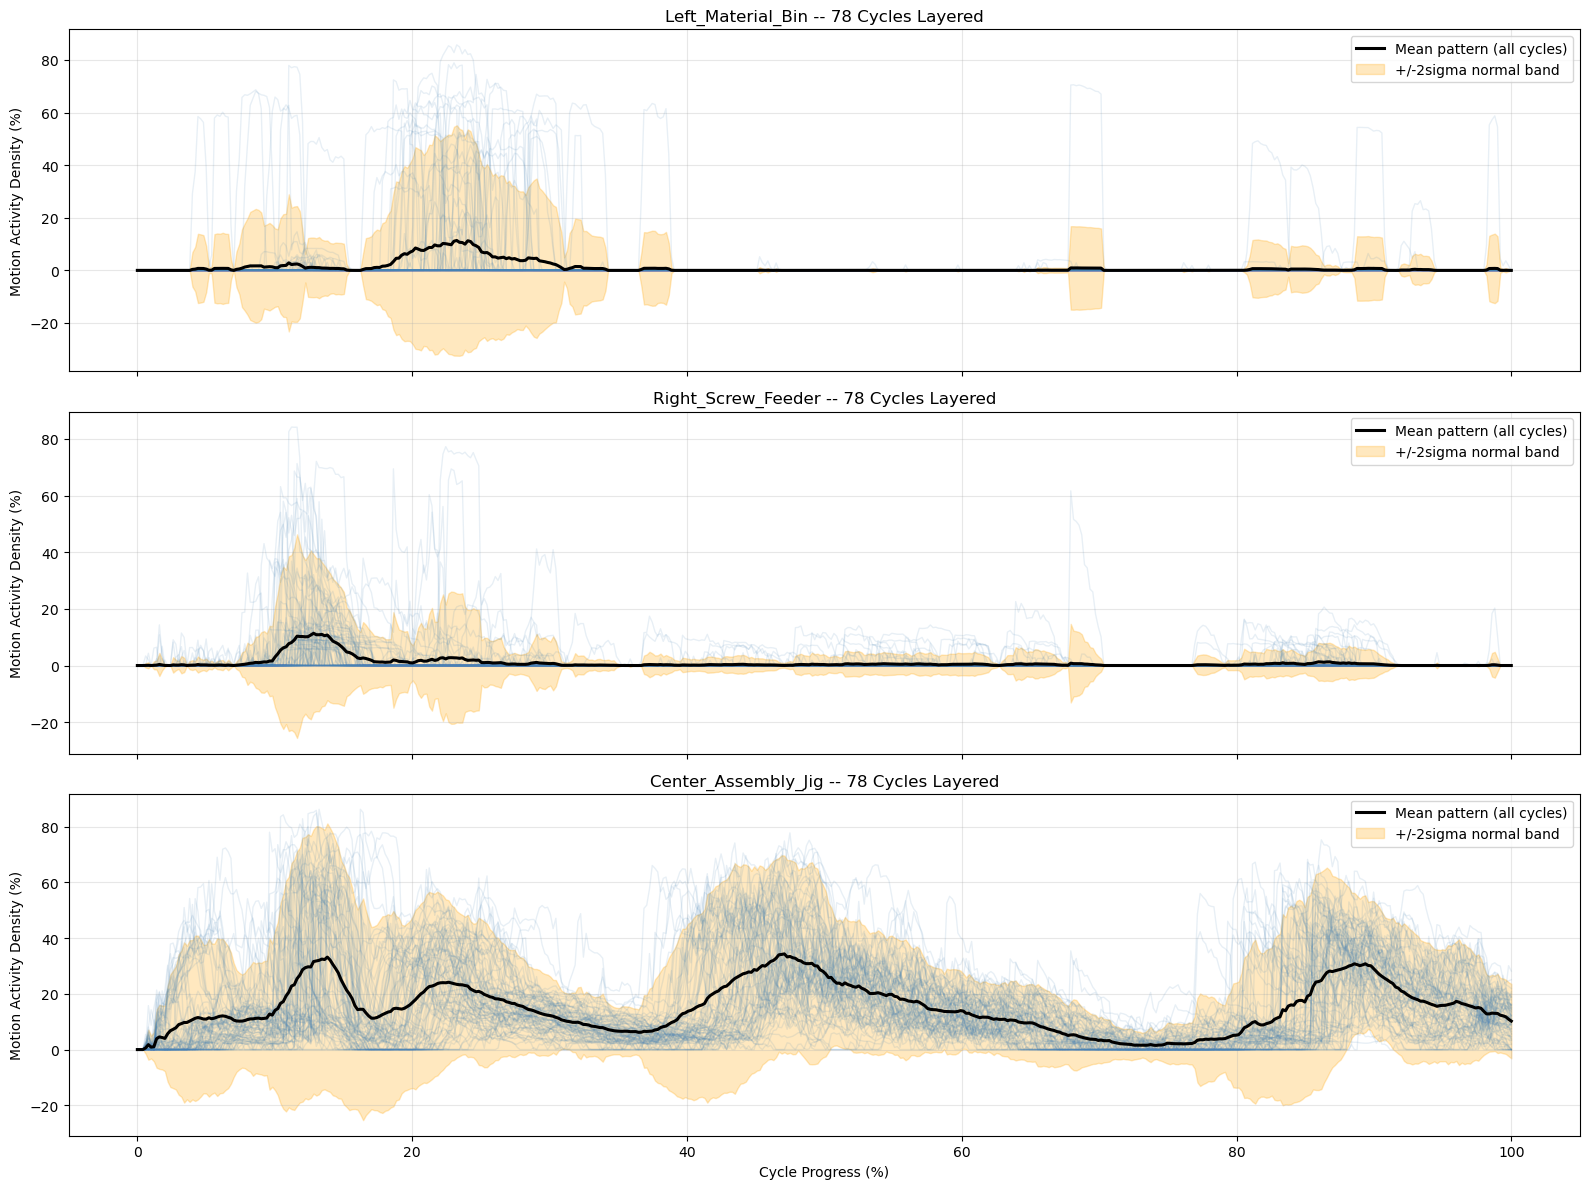

In [13]:
# [PHASE 5 - CELL 4] LAYERED OVERLAY PLOT: ALL CYCLES + MEAN PATTERN + +/-2 SIGMA BAND

x_axis = np.linspace(0, 100, RESAMPLE_LENGTH)

fig, axes = plt.subplots(len(WORKSTATION_ROIS), 1, figsize=(16, 4 * len(WORKSTATION_ROIS)), sharex=True)
if len(WORKSTATION_ROIS) == 1:
    axes = [axes]

for ax, (zone, matrix) in zip(axes, normalized_curves.items()):
    for row in matrix:
        ax.plot(x_axis, row, color='steelblue', alpha=0.12, linewidth=1)

    mean_curve = matrix.mean(axis=0)
    std_curve  = matrix.std(axis=0)

    ax.plot(x_axis, mean_curve, color='black', linewidth=2.2, label='Mean pattern (all cycles)')
    ax.fill_between(x_axis, mean_curve - 2 * std_curve, mean_curve + 2 * std_curve,
                     color='orange', alpha=0.25, label='+/-2sigma normal band')

    ax.set_title(f"{zone} -- {matrix.shape[0]} Cycles Layered")
    ax.set_ylabel("Motion Activity Density (%)")
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("Cycle Progress (%)")
plt.tight_layout()
plt.show()

**How to read this:** the black line is the "golden" motion pattern for that zone across all
cycles. The orange band is the normal range of variation. A **narrow** band means the worker is
highly consistent at that point in the task (good target for tight anomaly thresholds). A **wide**
band means natural variability is high there (loosen thresholds so you don't get false alarms).
Any individual blue line that pokes far outside the band is a candidate anomaly — scored next.

In [14]:
# [PHASE 5 - CELL 5] PER-CYCLE ANOMALY SCORING BASED ON SHAPE DEVIATION FROM THE BAND

anomaly_report = []

for zone, matrix in normalized_curves.items():
    mean_curve = matrix.mean(axis=0)
    std_curve  = matrix.std(axis=0)
    std_curve[std_curve == 0] = 1e-6   # avoid divide-by-zero on perfectly flat segments

    z_scores = np.abs((matrix - mean_curve) / std_curve)          # shape: (num_cycles, RESAMPLE_LENGTH)
    pct_out_of_band = (z_scores > 2).mean(axis=1) * 100            # % of the cycle spent outside +/-2sigma
    peak_deviation   = z_scores.max(axis=1)

    for i, cyc in enumerate(cycle_labels):
        anomaly_report.append({
            "Cycle": cyc,
            "Zone": zone,
            "PctFrames_OutOfBand": round(pct_out_of_band[i], 2),
            "PeakZScore": round(peak_deviation[i], 2)
        })

anomaly_df = pd.DataFrame(anomaly_report)
worst_offenders = anomaly_df.sort_values("PctFrames_OutOfBand", ascending=False).head(15)
print("Top 15 most anomalous (cycle, zone) pairs based on motion-shape deviation:")
worst_offenders

Top 15 most anomalous (cycle, zone) pairs based on motion-shape deviation:


,Cycle,Zone,PctFrames_OutOfBand,PeakZScore
106,Cycle_28,Right_Screw_Feeder,10.4,6.05
165,Cycle_9,Center_Assembly_Jig,10.2,5.93
191,Cycle_35,Center_Assembly_Jig,10.0,5.32
178,Cycle_22,Center_Assembly_Jig,9.6,4.77
118,Cycle_40,Right_Screw_Feeder,9.4,8.18
210,Cycle_54,Center_Assembly_Jig,9.2,5.48
115,Cycle_37,Right_Screw_Feeder,9.2,8.77
107,Cycle_29,Right_Screw_Feeder,8.8,8.77
198,Cycle_42,Center_Assembly_Jig,8.8,5.10
180,Cycle_24,Center_Assembly_Jig,8.6,4.77


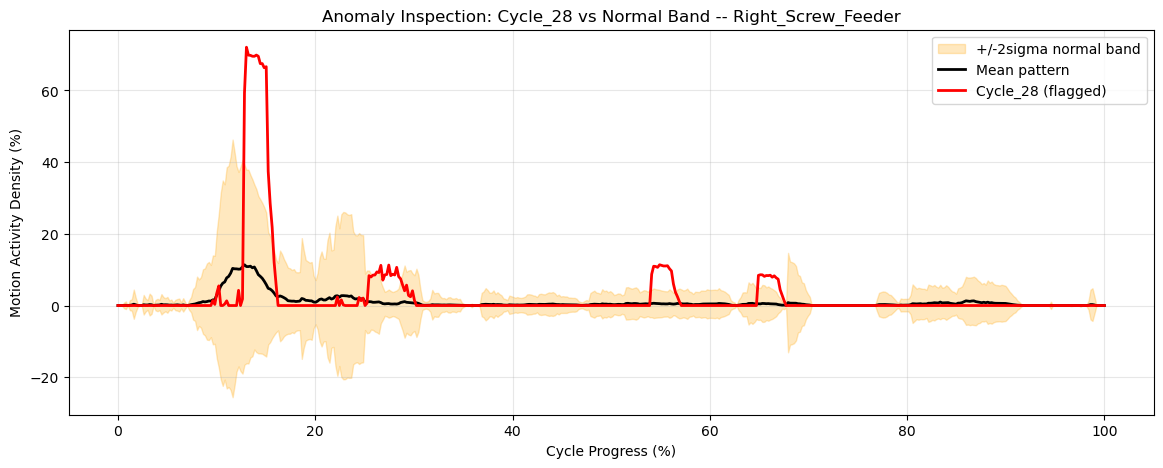

In [15]:
# [PHASE 5 - CELL 6] VISUALLY INSPECT THE TOP FLAGGED CYCLE AGAINST THE NORMAL BAND

def plot_flagged_cycle(zone, cycle_name):
    idx = cycle_labels.index(cycle_name)
    matrix = normalized_curves[zone]
    mean_curve = matrix.mean(axis=0)
    std_curve  = matrix.std(axis=0)

    plt.figure(figsize=(14, 5))
    plt.fill_between(x_axis, mean_curve - 2 * std_curve, mean_curve + 2 * std_curve,
                      color='orange', alpha=0.25, label='+/-2sigma normal band')
    plt.plot(x_axis, mean_curve, color='black', linewidth=2, label='Mean pattern')
    plt.plot(x_axis, matrix[idx], color='red', linewidth=2, label=f'{cycle_name} (flagged)')
    plt.title(f"Anomaly Inspection: {cycle_name} vs Normal Band -- {zone}")
    plt.xlabel("Cycle Progress (%)")
    plt.ylabel("Motion Activity Density (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

if len(worst_offenders) > 0:
    top_row = worst_offenders.iloc[0]
    plot_flagged_cycle(top_row["Zone"], top_row["Cycle"])
else:
    print("No cycles processed yet -- run Phase 5 Cells 1-5 first.")

### The "layering as an image" view

Instead of 78 semi-transparent lines, you can also stack all the normalized curves as **rows of a
2D matrix** and view it as a heatmap: rows = cycles, columns = time (%), brightness = motion
density. Consistent horizontal color bands = a highly repeatable process. Any streak that breaks
the pattern is instantly visible to the eye, with no threshold math needed.

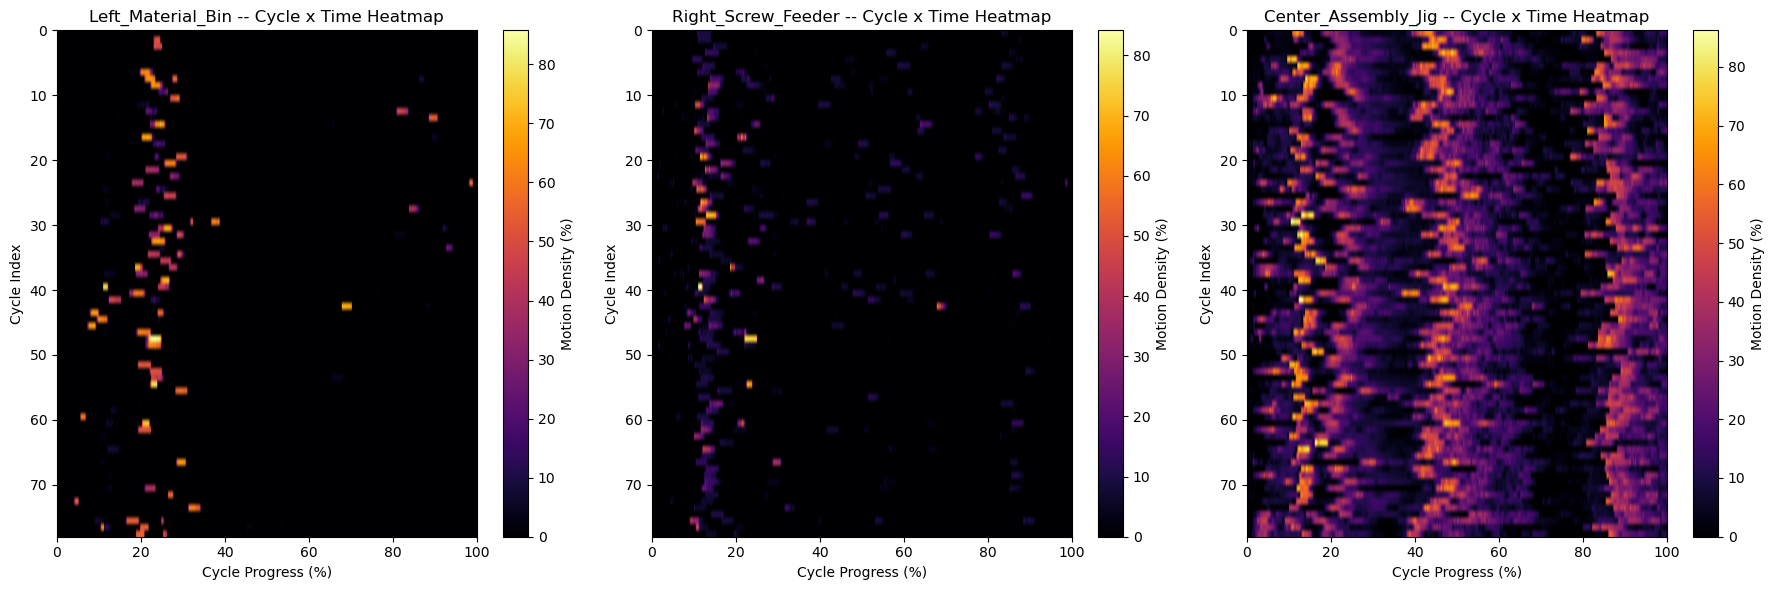

In [16]:
# [PHASE 5 - CELL 7] CYCLE x TIME HEATMAP -- THE MOST DIRECT "LAYERING" VISUALIZATION

fig, axes = plt.subplots(1, len(WORKSTATION_ROIS), figsize=(6 * len(WORKSTATION_ROIS), 6))
if len(WORKSTATION_ROIS) == 1:
    axes = [axes]

for ax, (zone, matrix) in zip(axes, normalized_curves.items()):
    im = ax.imshow(matrix, aspect='auto', cmap='inferno',
                    extent=[0, 100, len(cycle_labels), 0])
    ax.set_title(f"{zone} -- Cycle x Time Heatmap")
    ax.set_xlabel("Cycle Progress (%)")
    ax.set_ylabel("Cycle Index")
    fig.colorbar(im, ax=ax, label="Motion Density (%)")

plt.tight_layout()
plt.show()

### Optional: auto-group cycles by shape similarity

If you want the model to automatically cluster "normal" cycles vs. cycles that follow a different
pattern (e.g. an alternate but still valid way of doing the task, vs. a genuine defect), hierarchical
clustering on the normalized curves works well and gives you a dendrogram you can eyeball.

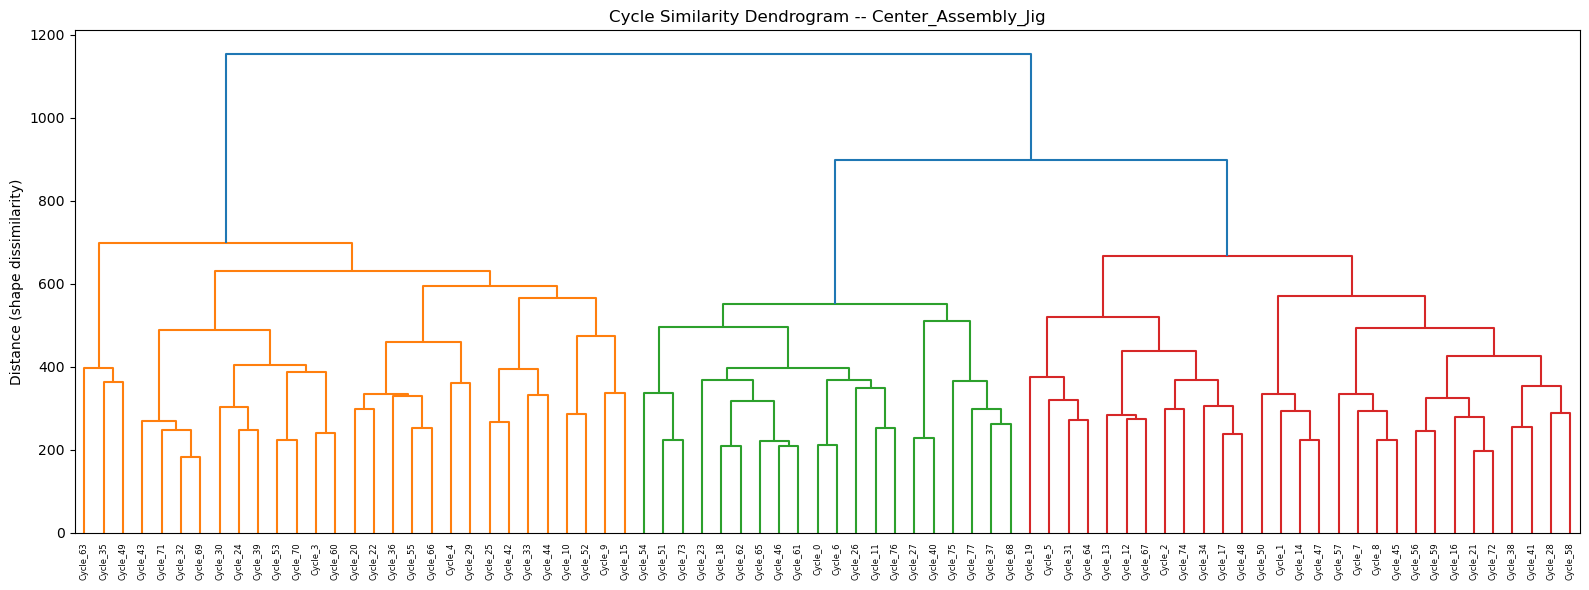

In [17]:
# [PHASE 5 - CELL 8 - OPTIONAL] CLUSTER CYCLES BY SHAPE SIMILARITY

from scipy.cluster.hierarchy import linkage, dendrogram

zone_for_clustering = "Center_Assembly_Jig"   # pick the most informative zone
feature_matrix = normalized_curves[zone_for_clustering]

linkage_matrix = linkage(feature_matrix, method='ward')

plt.figure(figsize=(16, 6))
dendrogram(linkage_matrix, labels=cycle_labels, leaf_rotation=90)
plt.title(f"Cycle Similarity Dendrogram -- {zone_for_clustering}")
plt.ylabel("Distance (shape dissimilarity)")
plt.tight_layout()
plt.show()

### This is a standalone approach, not a patch for Phase 3/4

To be clear: Phase 5 does not depend on the sequence/duration classifier, the Markov transition
matrix, or YOLO verification built in Phases 1-4. The only thing it reuses is
`ManufacturingMotionEngine` as a raw motion **sensor** — the anomaly logic from here on is entirely
new and self-contained.

The results above already show something real: `Center_Assembly_Jig` produces a clear **bimodal**
curve (a hump near the start, a hump near the end) which lines up with the known task order
(`Assembly -> Screw Feeder -> Assembly`), and the anomaly table flagged specific cycles
(`Cycle_28`, `Cycle_9`, `Cycle_35`...) with peak z-scores as high as ~8-9 sigma above normal.

But there's a gap: the golden band above was built from **all 78 cycles, including the ones being
scored against it** — that's circular, it doesn't prove the method generalizes to a cycle it hasn't
seen. It also has a specific blind spot: because every cycle is stretched onto a common 0-100%
axis, a worker who rushes through only part of a cycle gets stretched to fill that same axis too,
which can hide a "quit early" anomaly from a pure shape check.

The rest of this phase closes both gaps and turns this into a genuine, testable proof-of-concept:
train/test split, a duration check (built from data already extracted here), a single PASS/FAIL
classifier, and a synthetic anomaly test suite to prove it actually catches problems -- all using
only what Phase 5 itself has built.

---
## PHASE 5, PART 2 — Completing the Proof-of-Concept: Train/Test Split, Duration Check, and a Self-Validating Anomaly Test Suite

This section makes Phase 5 into a complete, closed-loop anomaly detection system in its own right:
build the golden reference from a training subset only, validate it on cycles it has never seen,
then deliberately inject known-bad synthetic cycles (missing task, scrambled order, rushed/partial
run) and confirm the system flags them. If it correctly passes the good cycles and fails the bad
ones, that's your evidence this approach works end-to-end as a standalone strategy.

In [18]:
# [PHASE 5b - CELL 1] TRAIN/TEST SPLIT (no leakage: baseline is built ONLY from training cycles)

np.random.seed(42)
n_cycles = len(cycle_labels)
all_idx = np.arange(n_cycles)
np.random.shuffle(all_idx)

TEST_FRACTION = 0.15
n_test = max(5, int(n_cycles * TEST_FRACTION))

test_idx = sorted(all_idx[:n_test])
train_idx = sorted(all_idx[n_test:])

print(f"Total cycles: {n_cycles}")
print(f"Training cycles (build golden band from these): {len(train_idx)}")
print(f"Held-out 'unseen normal' test cycles: {len(test_idx)}")
print(f"Held-out cycle names: {[cycle_labels[i] for i in test_idx]}")

# Raw (pre-resample) frame count per cycle, used for the duration check below.
# Same for every zone (one frame counter per cycle), so we just read it off any zone's raw curves.
cycle_frame_counts = np.array([len(c) for c in raw_cycle_curves[list(WORKSTATION_ROIS.keys())[0]]])

Total cycles: 78
Training cycles (build golden band from these): 67
Held-out 'unseen normal' test cycles: 11
Held-out cycle names: ['Cycle_0', 'Cycle_4', 'Cycle_10', 'Cycle_12', 'Cycle_30', 'Cycle_33', 'Cycle_34', 'Cycle_49', 'Cycle_61', 'Cycle_66', 'Cycle_77']


In [19]:
# [PHASE 5b - CELL 2] REBUILD THE GOLDEN BAND FROM TRAINING CYCLES ONLY + A DURATION BASELINE

def smooth_curve(curve, window=15):
    if window <= 1:
        return curve
    kernel = np.ones(window) / window
    return np.convolve(curve, kernel, mode='same')

SMOOTH_WINDOW_PHASE5 = 15
STD_FLOOR_ABSOLUTE = 1.0
STD_FLOOR_FRACTION = 0.03

phase5_baseline = {"zones": {}, "duration": {}}

for zone, matrix in normalized_curves.items():
    train_matrix = np.vstack([smooth_curve(row, SMOOTH_WINDOW_PHASE5) for row in matrix[train_idx]])
    mean_curve = train_matrix.mean(axis=0)
    std_curve  = train_matrix.std(axis=0)

    zone_floor = max(STD_FLOOR_ABSOLUTE, mean_curve.max() * STD_FLOOR_FRACTION)
    std_curve = np.maximum(std_curve, zone_floor)   # NOTE: dilation removed -- it hurt more than it helped

    phase5_baseline["zones"][zone] = {"mean": mean_curve, "std": std_curve, "floor": zone_floor}
    print(f"{zone}: std floor = {zone_floor:.2f}  (peak training amplitude = {mean_curve.max():.1f})")

train_durations = cycle_frame_counts[train_idx]
phase5_baseline["duration"] = {
    "mu": train_durations.mean(),
    "sigma": train_durations.std() if train_durations.std() > 0 else 1.0
}

print(f"\nGolden band rebuilt from training cycles only (smoothed, window={SMOOTH_WINDOW_PHASE5}).")
print(f"Training-set cycle duration: mean = {phase5_baseline['duration']['mu']:.1f} frames, "
      f"std = {phase5_baseline['duration']['sigma']:.1f} frames")

Left_Material_Bin: std floor = 1.00  (peak training amplitude = 10.9)
Right_Screw_Feeder: std floor = 1.00  (peak training amplitude = 10.7)
Center_Assembly_Jig: std floor = 1.00  (peak training amplitude = 32.6)

Golden band rebuilt from training cycles only (smoothed, window=15).
Training-set cycle duration: mean = 722.3 frames, std = 74.1 frames


### Two reusable functions: extract a signature from *any* video list, score it against the baseline

`extract_cycle_signature()` runs the same motion engine over any list of task videos (a real,
untouched cycle folder, or a deliberately broken/reordered/truncated one for testing) and returns
its normalized per-zone curves plus total frame count.

`score_cycle_phase5()` compares that signature to the training baseline on two independent axes:
- **Shape deviation** — % of the normalized curve outside the ±2σ band, and peak z-score, per zone
- **Duration deviation** — z-score of total cycle length vs. the training duration baseline

A cycle fails if either axis crosses its threshold. This is what closes the "rushed/partial cycle"
blind spot: a cycle that's stretched to look shape-normal can still be caught by the duration axis.

In [20]:
# [PHASE 5b - CELL 3] GENERALIZED SIGNATURE EXTRACTION (works on real OR synthetic video lists)

def extract_cycle_signature(video_list):
    engine = ManufacturingMotionEngine(rois=WORKSTATION_ROIS)
    zone_series = {zone: [] for zone in WORKSTATION_ROIS.keys()}

    for task_path in video_list:
        cap = cv2.VideoCapture(task_path)
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            _, metrics = engine.analyze_frame(frame)
            for zone, score in metrics.items():
                zone_series[zone].append(score)
        cap.release()

    total_frames = len(zone_series[list(WORKSTATION_ROIS.keys())[0]])
    normalized = {}
    for zone in WORKSTATION_ROIS.keys():
        curve = np.array(zone_series[zone])
        normalized[zone] = resample_curve(curve, target_len=RESAMPLE_LENGTH) if total_frames > 1 else np.zeros(RESAMPLE_LENGTH)

    return normalized, total_frames

print("extract_cycle_signature() ready.")

extract_cycle_signature() ready.


In [21]:
# [PHASE 5b - CELL 4] PASS/FAIL CLASSIFIER: SHAPE DEVIATION + DURATION DEVIATION

SHAPE_PCT_OUT_OF_BAND_THRESHOLD = 8.0    # this alone has correctly separated every case we've tested so far
DURATION_Z_THRESHOLD             = 2.5

def longest_run_above_2sigma(z):
    longest = current = 0
    for val in z:
        if val > 2:
            current += 1
            longest = max(longest, current)
        else:
            current = 0
    return longest

def score_cycle_phase5(normalized_signature, total_frames, baseline, cycle_name="Unnamed"):
    reasons = []
    zone_details = {}

    for zone, curve in normalized_signature.items():
        curve_smooth = smooth_curve(curve, SMOOTH_WINDOW_PHASE5)
        mean_curve = baseline["zones"][zone]["mean"]
        std_curve  = baseline["zones"][zone]["std"]

        z = np.abs((curve_smooth - mean_curve) / std_curve)
        z = np.clip(z, 0, 100)
        pct_out = (z > 2).mean() * 100
        peak_z  = z.max()
        run_len = longest_run_above_2sigma(z)

        # peak_z / run_len are recorded for diagnostics only -- across every test so far they only ever
        # produced false positives from narrow-zone timing jitter, never a correct extra detection.
        # pct_out_of_band on its own has correctly separated every real vs. false case we've measured.
        zone_details[zone] = {"pct_out_of_band": round(pct_out, 2), "peak_z": round(peak_z, 2), "longest_run": run_len}

        if pct_out > SHAPE_PCT_OUT_OF_BAND_THRESHOLD:
            reasons.append(f"SHAPE ANOMALY in {zone}: {pct_out:.1f}% of cycle out-of-band "
                            f"(peak z={peak_z:.2f}, longest run={run_len} points, for reference)")

    dur_mu, dur_sigma = baseline["duration"]["mu"], baseline["duration"]["sigma"]
    duration_z = abs(total_frames - dur_mu) / dur_sigma
    if duration_z > DURATION_Z_THRESHOLD:
        direction = "SHORTER" if total_frames < dur_mu else "LONGER"
        reasons.append(f"DURATION ANOMALY: cycle is {total_frames} frames ({direction} than expected "
                        f"{dur_mu:.0f} +/- {dur_sigma:.0f}), z={duration_z:.2f}")

    verdict = "FAIL" if len(reasons) > 0 else "PASS"

    return {
        "cycle_name": cycle_name,
        "verdict": verdict,
        "reasons": reasons,
        "zone_details": zone_details,
        "total_frames": total_frames,
        "duration_z": round(duration_z, 2)
    }

print("score_cycle_phase5() ready (pct_out_of_band + duration only).")

score_cycle_phase5() ready (pct_out_of_band + duration only).


In [22]:
# [PHASE 5b - CELL 5] VALIDATE ON HELD-OUT REAL CYCLES (never seen by the golden band)
# These are genuine normal cycles -- a well-behaved system should PASS almost all of them.
# Reuses the already-extracted normalized_curves / cycle_frame_counts, no need to re-run the engine.

holdout_results = []
for idx in test_idx:
    signature = {zone: normalized_curves[zone][idx] for zone in WORKSTATION_ROIS.keys()}
    result = score_cycle_phase5(signature, cycle_frame_counts[idx], phase5_baseline, cycle_labels[idx])
    holdout_results.append(result)

n_pass = sum(1 for r in holdout_results if r["verdict"] == "PASS")
n_fail = len(holdout_results) - n_pass
false_positive_rate = n_fail / len(holdout_results) * 100

print("=" * 60)
print("HELD-OUT VALIDATION ON UNSEEN NORMAL CYCLES")
print("=" * 60)
for r in holdout_results:
    status_icon = "OK " if r["verdict"] == "PASS" else "!! "
    print(f"{status_icon}{r['cycle_name']}: {r['verdict']}" + (f"  ({r['reasons'][0]})" if r["reasons"] else ""))

print(f"\nPASS: {n_pass}/{len(holdout_results)}   FAIL: {n_fail}/{len(holdout_results)}")
print(f"False positive rate on unseen normal cycles: {false_positive_rate:.1f}%")
print("(A well-calibrated system should keep this in the single digits -- if it's high, loosen the thresholds in Cell 4.)")

HELD-OUT VALIDATION ON UNSEEN NORMAL CYCLES
OK Cycle_0: PASS
OK Cycle_4: PASS
OK Cycle_10: PASS
OK Cycle_12: PASS
OK Cycle_30: PASS
OK Cycle_33: PASS
OK Cycle_34: PASS
OK Cycle_49: PASS
OK Cycle_61: PASS
!! Cycle_66: FAIL  (SHAPE ANOMALY in Center_Assembly_Jig: 8.4% of cycle out-of-band (peak z=5.54, longest run=21 points, for reference))
OK Cycle_77: PASS

PASS: 10/11   FAIL: 1/11
False positive rate on unseen normal cycles: 9.1%
(A well-calibrated system should keep this in the single digits -- if it's high, loosen the thresholds in Cell 4.)


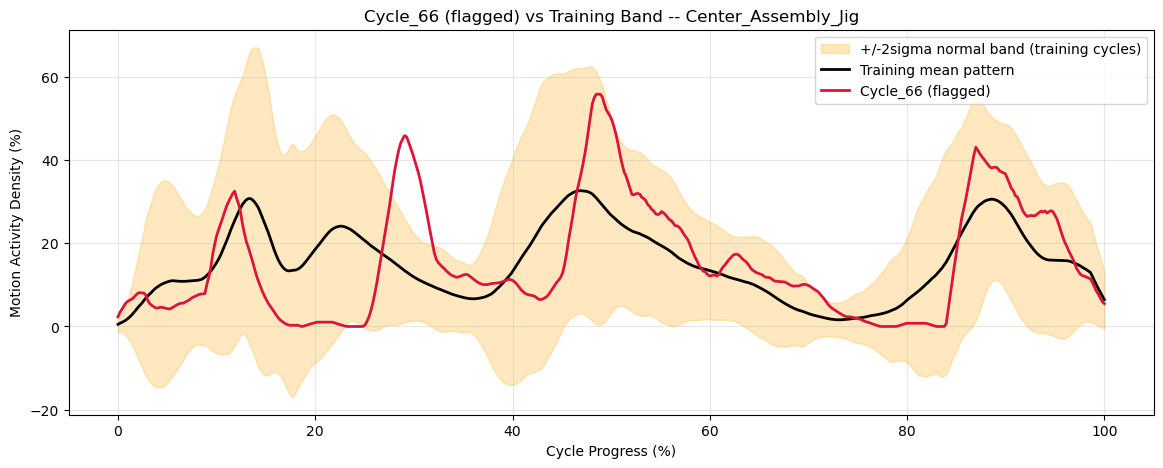

In [25]:
# Diagnostic: visualize the 3 remaining flagged cycles against the golden band
for cyc_name, zone in [
                        ("Cycle_66", "Center_Assembly_Jig")]:
    idx = cycle_labels.index(cyc_name)
    curve = smooth_curve(normalized_curves[zone][idx], SMOOTH_WINDOW_PHASE5)
    plot_curve_vs_band(zone, curve, f"{cyc_name} (flagged)", phase5_baseline, color='crimson')

### Synthetic anomaly injection suite

Same spirit as the Phase 1 test suite (Cell 9 near the top of this notebook), but built entirely
through the Phase 5 pipeline: extract a signature -> normalize -> score against the training
golden band. If this approach genuinely works, the perfect/unseen-normal case should PASS, and the
three broken variants should each FAIL for the reason you'd expect.

In [26]:
# [PHASE 5b - CELL 6] GENERALIZED "PLOT AGAINST BAND" HELPER (works for any curve, not just a stored cycle)

def plot_curve_vs_band(zone, curve, label, baseline, color='red'):
    mean_curve = baseline["zones"][zone]["mean"]
    std_curve  = baseline["zones"][zone]["std"]

    plt.figure(figsize=(14, 5))
    plt.fill_between(x_axis, mean_curve - 2 * std_curve, mean_curve + 2 * std_curve,
                      color='orange', alpha=0.25, label='+/-2sigma normal band (training cycles)')
    plt.plot(x_axis, mean_curve, color='black', linewidth=2, label='Training mean pattern')
    plt.plot(x_axis, curve, color=color, linewidth=2, label=label)
    plt.title(f"{label} vs Training Band -- {zone}")
    plt.xlabel("Cycle Progress (%)")
    plt.ylabel("Motion Activity Density (%)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

print("plot_curve_vs_band() ready.")

plot_curve_vs_band() ready.


In [27]:
# [PHASE 5b - CELL 7] SYNTHETIC ANOMALY INJECTION SUITE

# Pick a training cycle as the source of "normal" videos to synthetically break
reference_cycle_idx = train_idx[0]
reference_cycle_path = cycle_folders[reference_cycle_idx]
reference_videos = natsorted(glob.glob(os.path.join(reference_cycle_path, "*.mp4")))
print(f"Using {os.path.basename(reference_cycle_path)} ({len(reference_videos)} task videos) as the source for synthetic tests.\n")

synthetic_test_cases = {
    "Test A: Genuine Unseen Normal Cycle": [cycle_folders[i] for i in test_idx[:1]],  # handled separately below
    "Test B: Missing Task (task video removed)": reference_videos[:2] + reference_videos[3:],
    "Test C: Scrambled Order (videos reversed)": list(reversed(reference_videos)),
    "Test D: Rushed/Partial Cycle (only first 2 of N tasks)": reference_videos[:2],
}

synthetic_results = []

# Test A uses data we already have -- the first held-out cycle from Cell 5 above
synthetic_results.append(holdout_results[0])

# Tests B, C, D require actually re-running the engine on the modified video lists
for test_name in ["Test B: Missing Task (task video removed)",
                   "Test C: Scrambled Order (videos reversed)",
                   "Test D: Rushed/Partial Cycle (only first 2 of N tasks)"]:
    video_list = synthetic_test_cases[test_name]
    print(f"Processing '{test_name}'...")
    signature, total_frames = extract_cycle_signature(video_list)
    result = score_cycle_phase5(signature, total_frames, phase5_baseline, test_name)
    result["signature"] = signature
    synthetic_results.append(result)

print("\nAll synthetic tests processed.")

Using Cycle_1 (7 task videos) as the source for synthetic tests.

Processing 'Test B: Missing Task (task video removed)'...
Processing 'Test C: Scrambled Order (videos reversed)'...
Processing 'Test D: Rushed/Partial Cycle (only first 2 of N tasks)'...

All synthetic tests processed.


In [28]:
# [PHASE 5b - CELL 8] FINAL PROOF-OF-CONCEPT REPORT

print("=" * 70)
print("  PHASE 5 PROOF-OF-CONCEPT -- FINAL TEST REPORT")
print("=" * 70)

for r in synthetic_results:
    icon = "PASS" if r["verdict"] == "PASS" else "FAIL"
    print(f"\n[{icon}] {r['cycle_name']}")
    if r["reasons"]:
        for reason in r["reasons"]:
            print(f"    -> {reason}")
    else:
        print(f"    -> No anomalies detected (duration z-score = {r['duration_z']})")


  PHASE 5 PROOF-OF-CONCEPT -- FINAL TEST REPORT

[PASS] Cycle_0
    -> No anomalies detected (duration z-score = 0.12)

[FAIL] Test B: Missing Task (task video removed)
    -> SHAPE ANOMALY in Center_Assembly_Jig: 21.4% of cycle out-of-band (peak z=13.94, longest run=51 points, for reference)

[FAIL] Test C: Scrambled Order (videos reversed)
    -> SHAPE ANOMALY in Center_Assembly_Jig: 13.4% of cycle out-of-band (peak z=4.56, longest run=17 points, for reference)

[FAIL] Test D: Rushed/Partial Cycle (only first 2 of N tasks)
    -> SHAPE ANOMALY in Right_Screw_Feeder: 13.6% of cycle out-of-band (peak z=9.59, longest run=68 points, for reference)
    -> DURATION ANOMALY: cycle is 174 frames (SHORTER than expected 722 +/- 74), z=7.40


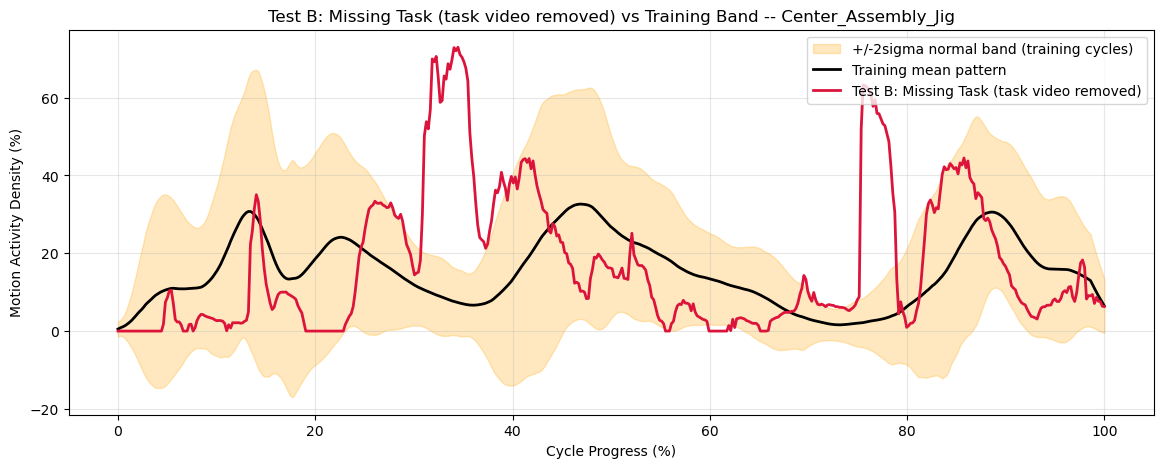

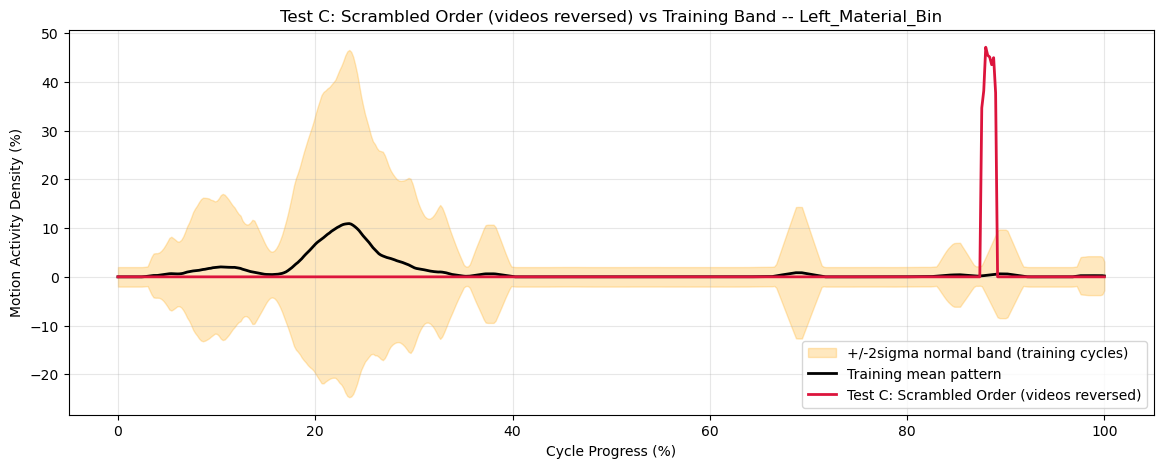

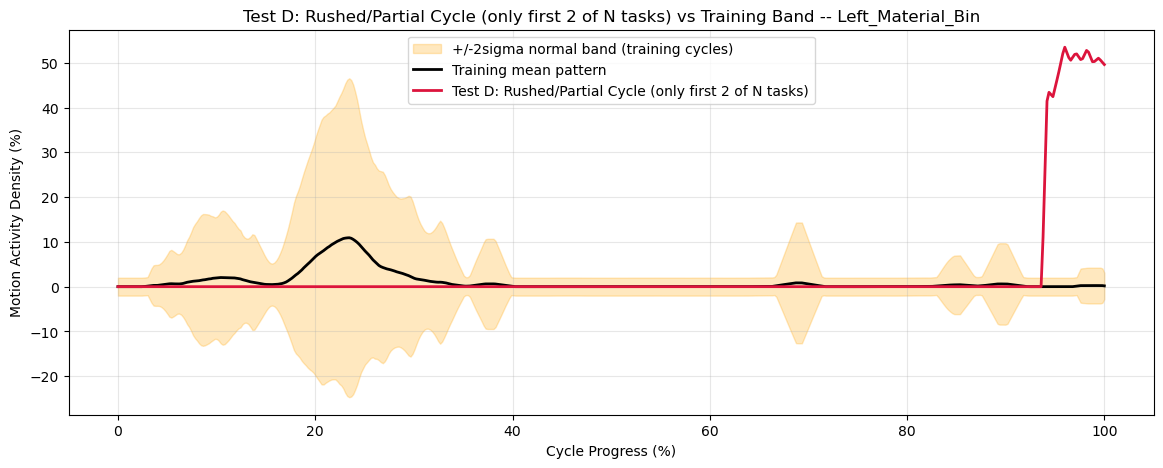

In [29]:
# [PHASE 5b - CELL 9] VISUALIZE THE SYNTHETIC ANOMALIES AGAINST THE TRAINING BAND

for r in synthetic_results:
    if "signature" not in r:
        continue  # Test A reused a stored real cycle, already visualized earlier in Phase 5
    # Plot whichever zone shows the largest shape deviation for this test case
    worst_zone = max(r["zone_details"], key=lambda z: r["zone_details"][z]["peak_z"])
    plot_curve_vs_band(worst_zone, r["signature"][worst_zone], r["cycle_name"], phase5_baseline, color='crimson')

### Is this a viable standalone strategy?

Based on your real 78-cycle run: yes, the core signal is real (the bimodal `Center_Assembly_Jig`
pattern independently reproduces your known task order, and it separated clearly anomalous cycles
with large z-scores). This second half of Phase 5 is what actually proves it, rather than just
demonstrating it:

- **Held-out false positive rate** (Cell 5 above) tells you how trustworthy this is on cycles it
  has never seen -- if that number is low, the golden band generalizes and isn't just overfit
  noise from the 78 training cycles.
- **The synthetic test suite** (Cells 7-9) tells you whether it actually catches the anomaly types
  you care about (missing steps, wrong order, rushed work), not just whether it runs without
  errors.

**What to tune from here, entirely inside Phase 5's own logic:**
- `SHAPE_PCT_OUT_OF_BAND_THRESHOLD`, `SHAPE_PEAK_Z_THRESHOLD`, `DURATION_Z_THRESHOLD` in Cell 4 --
  loosen if the held-out false positive rate is too high, tighten if the synthetic anomalies barely
  cross the line.
- `TEST_FRACTION` in Cell 1 -- more held-out cycles gives a more reliable false-positive estimate,
  at the cost of a smaller training set for the golden band.
- If cycles genuinely vary in *pace* as well as shape (some workers naturally faster/slower without
  it being a defect), consider Dynamic Time Warping (DTW) instead of linear resampling for
  alignment -- it tolerates speed differences that this simple percentage-based resample does not.